In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [17]:
df = pd.read_csv('../praktikum1/Hospital_Indonesia_datasets - DataCleaning.csv')

df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,median_total_tempat_tidur,total_tempat_tidur,median_total_tenaga,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,218,328,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,45,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,310,487,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,11,182,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,Rumah Sakit Umum,C,BLUD,Pemkot,189,189,537,34,537


In [18]:
print(f"Jenis: \n {df['jenis'].unique()}\n")
print(f"Kelas: \n {df['kelas'].unique()}\n")
print(f"status_blu: \n {df['status_blu'].unique()}\n")
print(f"Kepemilikan: \n {df['kepemilikan'].unique()}\n")

Jenis: 
 ['Rumah Sakit Umum' 'Rumah Sakit Khusus Gigi dan Mulut'
 'Rumah Sakit Khusus Ibu dan Anak' 'Rumah Sakit Khusus Jiwa'
 'Rumah Sakit Khusus Bedah' 'Rumah Sakit Khusus Mata'
 'Rumah Sakit Khusus Paru' 'Rumah Sakit Khusus Ginjal'
 'Rumah Sakit Khusus Stroke' 'Rumah Sakit Khusus THT-KL'
 'Rumah Sakit Khusus Kanker' 'Rumah Sakit Khusus Infeksi'
 'Rumah Sakit Khusus Jantung' 'Rumah Sakit Khusus Otak'
 'Rumah Sakit Ketergantungan Obat' 'Rumah Sakit Khusus Orthopedi'
 'RS Kapal/Bergerak']

Kelas: 
 ['C' 'D' 'B' 'D PRATAMA' 'A' 'Belum Ditetapkan' 'Rumah Sakit Umum'
 'Rumah Sakit Khusus Jiwa']

status_blu: 
 ['Non BLU/BLUD' 'BLUD' 'BLU' 'D' 'A' 'C' 'D PRATAMA']

Kepemilikan: 
 ['SWASTA/LAINNYA' 'Pemkot' 'Kementerian Lain' 'Pemkab' 'Perusahaan'
 'Organisasi Sosial' 'POLRI' 'TNI AD' 'TNI AL' 'BUMN' 'Pemprop'
 'Perorangan' 'Organisasi Katholik' 'Organisasi Protestan' 'Kemkes'
 'TNI AU' 'Organisasi Islam' 'Organisasi Budha' 'BLUD' 'BLU'
 'Non BLU/BLUD' 'Organisasi Hindu']



Cleaning

In [19]:
df[df['kelas'] == 'D PRATAMA'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
25,RS Umum Daerah Type D Pratama T. Cut Ali,D PRATAMA,Rumah Sakit Umum
32,RS Umum Daerah dr. Muchtar Hasbi,D PRATAMA,Rumah Sakit Umum
99,RS Pratama Kab. Nias Barat,D PRATAMA,Rumah Sakit Umum
244,RS Pratama Lologolu Soguna Ba Zato,D PRATAMA,Rumah Sakit Umum
312,RS Umum Daerah Kamang Baru,D PRATAMA,Rumah Sakit Umum
...,...,...,...
3117,RS Umum Daerah Pratama Dogiyai,D PRATAMA,Rumah Sakit Umum
3138,RS Umum Daerah Ilaga,D PRATAMA,Rumah Sakit Umum
3144,RS Bergerak Kab. Boven Digoel,D PRATAMA,Rumah Sakit Umum
3146,RS Umum Daerah Karubaga,D PRATAMA,Rumah Sakit Umum


In [20]:
df[df['kelas'] == 'Rumah Sakit Khusus Jiwa'][['nama', 'kelas', 'jenis']]

,nama,kelas,jenis
1746,RS Khusus Jiwa Puri Nirmala,Rumah Sakit Khusus Jiwa,Rumah Sakit Umum


In [21]:
df.loc[
    df['nama'] == 'RS Umum Daerah Kepulauan Seribu',
    'kelas'
] = 'D'

df.loc[
    df['nama'] == 'RS Umum Pusat Dr. Soeradji Tirtonegoro',
    'kelas'
] = 'A'

df.loc[
    df['nama'] == 'RS Umum Daerah Kawera',
    'kelas'
] = 'D PRATAMA'

df.loc[
    df['kelas'] == 'Rumah Sakit Khusus Jiwa',
    'kelas'
] = 'C'

In [22]:
kelas_mapping = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'D PRATAMA': 0,
    'Belum Ditetapkan': -1 # Menambahkan nilai untuk 'Belum Ditetapkan'
}

df['kelas'] = df['kelas'].map(kelas_mapping)

In [23]:
df = pd.get_dummies(
    df,
    columns=['jenis', 'kepemilikan'],
)

In [24]:
df.head()

,id,nama,propinsi,kab,alamat,kelas,status_blu,median_total_tempat_tidur,total_tempat_tidur,median_total_tenaga,...,kepemilikan_POLRI,kepemilikan_Pemkab,kepemilikan_Pemkot,kepemilikan_Pemprop,kepemilikan_Perorangan,kepemilikan_Perusahaan,kepemilikan_SWASTA/LAINNYA,kepemilikan_TNI AD,kepemilikan_TNI AL,kepemilikan_TNI AU
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,2,Non BLU/BLUD,218,218,328,...,False,False,False,False,False,False,True,False,False,False
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,1,Non BLU/BLUD,45,45,45,...,False,False,False,False,False,False,True,False,False,False
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,3,BLUD,310,310,487,...,False,False,True,False,False,False,False,False,False,False
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,3,BLU,11,11,182,...,False,False,False,False,False,False,False,False,False,False
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) Kec...,2,BLUD,189,189,537,...,False,False,True,False,False,False,False,False,False,False


Feature Selection

In [25]:
df_cluster = df.drop(columns=['id', 'nama', 'propinsi', 'kab', 'alamat', 'status_blu'])

Normalisasi

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

Modelling

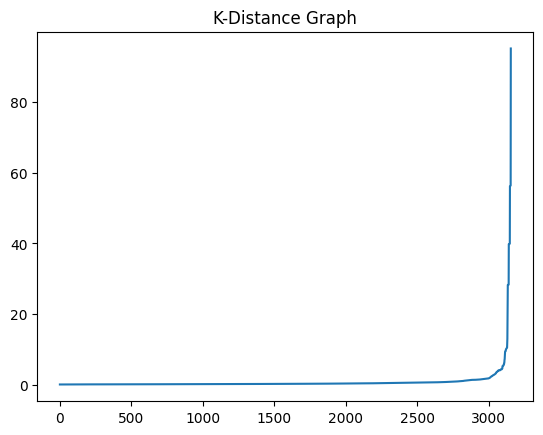

In [28]:

neighbors = NearestNeighbors(n_neighbors=5)

distances, _ = neighbors.fit(X_scaled).kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title('K-Distance Graph')
plt.show()

In [30]:
best_score = -1

for eps in np.arange(2, 5.1, 0.1):
    
    for min_samples in range(120, 140):
        
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = model.fit_predict(X_scaled)
        
        # cek jumlah cluster
        if len(set(labels)) > 2:
            
            score = silhouette_score(X_scaled, labels)
            
            # simpan model terbaik
            if score > best_score:
                
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

Evaluasi

In [31]:
print("Best EPS:", best_eps)
print("Best Min Samples:", best_min_samples)

print("Best Silhouette Score:",
      round(best_score, 4)
      )

Best EPS: 2.7000000000000006
Best Min Samples: 128
Best Silhouette Score: 0.27


In [32]:
unique, count = np.unique(best_labels, return_counts=True)
for label, count in zip(unique, count):
    if label == -1:
        print(f"Noise: {count} titik")
    else:
        print(f"Cluster {label}: {count} titik")

Noise: 1056 titik
Cluster 0: 665 titik
Cluster 1: 643 titik
Cluster 2: 395 titik
Cluster 3: 152 titik
Cluster 4: 244 titik


In [33]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

cluster = dbscan.fit_predict(X_scaled)
df['cluster'] = cluster

In [34]:
cluster_summary = df.groupby('cluster')[[
    'median_total_tempat_tidur',
    'total_layanan',
    'median_total_tenaga'
]].mean()

print(cluster_summary)

         median_total_tempat_tidur  total_layanan  median_total_tenaga
cluster                                                               
-1                      167.573864      41.843750           336.525568
 0                      115.403008      44.499248           222.624060
 1                      146.418351      39.646967           356.916019
 2                      118.660759      44.220253           216.513924
 3                       38.875000      19.559211            96.605263
 4                      115.557377      40.778689           239.356557


In [68]:
import plotly.io as pio
pio.renderers.default = "browser"

# PCA 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Buat Dataframe sederhana
df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Cluster': cluster
})

# 3D Interaktif Plot
fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='DBSCAN + PCA 3D (Interactive)'
)

fig.show()
